# Refined Stage 2 - corrected granularity baseline

Same experiment as the original Stage 2. Same data, same five series (seed 7), same three
models, same granularity ladder. **Only the measurement changed.**

| # | Fixed | Why it mattered |
|---|---|---|
| 1 | MASE scale computed once per (series, granularity) from a fixed reference segment, using the true seasonal period | The old `min(m, ctx-1)` clamp turned wind's m=1440 into 511, then the `ctx.size - m < 16` fallback dropped it to 1. The denominator became the mean 1-minute change — about 12x smaller than the hourly denominator. That, not forecast error, is most of the reported MASE 19.077. |
| 2 | Forecast origins anchored; context declared per cell instead of silently shrunk | `ctx = min(CONTEXT_LENGTH, st)` meant daily solar and wind actually ran at 225-351, not 512. |
| 3 | Constant-target windows detected and excluded | 11 wind-native windows scored MAE exactly 0 (one farm is flat); 49% of solar-native windows scored MASE < 0.10 (night). Those are not forecasts. |
| 4 | Median and IQR reported next to the mean | On the original results the per-cell winner flips in 3 of 9 cells depending on which you use. |
| 5 | Every per-window diagnostic saved | Any future metric change becomes a pandas operation instead of another GPU run. |

Nothing here changes what the models were asked to do, so the numbers stay comparable to
the original run — that comparison is made explicitly at the end.

> **What this notebook does not fix.** Horizon still co-varies with granularity
> (48 / 24 / 14 steps). Any granularity claim from this notebook is provisional until
> `refined_stage3d_fixed_lead_time` tests the same comparison at matched lead time.

In [ ]:
import sys, os, warnings, importlib
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import refined_stage_common as C

# A kernel that imported an older refined_stage_common keeps serving it from cache, and
# the failure surfaces much later as a missing column. Reload, then verify.
importlib.reload(C)
REQUIRED = "2026.09.10-relmae"
assert getattr(C, "__version__", None) == REQUIRED, (
    f"stale refined_stage_common (got {getattr(C, '__version__', 'none')}, "
    f"need {REQUIRED}) — restart the kernel and Run All")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
PALETTE = {"chronos": "#2563eb", "timesfm": "#059669", "moirai": "#d97706"}
print(f"common module {C.__version__} from {C.__file__}")

common module 2026.09.10-relmae from e:\Thesis\EnergyForcastModel\refined_stage_common.py


## 1. Data - the same five series per type, seed 7

Cached to disk, so the other refined notebooks reuse it without re-downloading Monash.

In [ ]:
DATA = C.get_data()
for et, lst in DATA.items():
    print(f"{et:6s} {len(lst)} series | native points "
          f"{min(len(s) for s in lst):,}–{max(len(s) for s in lst):,}")

loaded cached panel <- refined_panel_cache.pkl
  load   5 series, 230,736–232,272 points
  solar  5 series, 52,560–52,560 points
  wind   5 series, 434,876–434,876 points
load   5 series | native points 230,736–232,272
solar  5 series | native points 52,560–52,560
wind   5 series | native points 434,876–434,876


## 2. Configuration

Horizons are kept at the original values so the run stays comparable. The context is now
**planned per cell** — the largest each series can supply with origins anchored — and the
plan is printed before anything runs, instead of being silently reduced inside the loop.

In [ ]:
HORIZONS   = {"native": 48, "1h": 24, "1D": 14}   # unchanged from the original Stage 2
N_WINDOWS  = 10
CONTEXT_CAP = 512                                  # the original nominal context

plan = C.plan_contexts(DATA, HORIZONS, n_windows=N_WINDOWS, cap=CONTEXT_CAP)
CONTEXTS = {(r.etype, r.gran): r.max_context for r in plan.itertuples()}

etype   gran  horizon_steps max_context history   lead
 load native             48         512  10.7 d  1.0 d
 load     1h             24         512  21.3 d  1.0 d
 load     1D             14         512 512.0 d 14.0 d
solar native             48         512   3.6 d  8.0 h
solar     1h             24         512  21.3 d  1.0 d
solar     1D             14         225 225.0 d 14.0 d
 wind native             48         512   8.5 h 48 min
 wind     1h             24         512  21.3 d  1.0 d
 wind     1D             14         162 162.0 d 14.0 d


Read the `history` column carefully — it is the point of the whole thesis. The same
nominal context of 512 steps is 8.5 hours of wind and 10.7 days of demand, because the
metering rate differs. Any cell whose history is shorter than one day cannot see a daily
cycle at all.

In [ ]:
WINDOWS = C.build_windows(DATA, context_steps=CONTEXTS, horizon_steps=HORIZONS,
                          n_windows=N_WINDOWS)
print()
print(pd.DataFrame([w.meta() for w in WINDOWS])
        .groupby(["etype", "gran"])
        .agg(n=("m", "size"), context=("context_steps", "first"),
             horizon=("horizon_steps", "first"), m=("m", "first"),
             scale=("scale", "median"), degenerate=("degenerate", "sum"))
        .to_string())

450 windows built (context=[162, 225, 512], n_windows=10)
  seasonal-naive benchmark available for 450/450 windows (relMAE); MASE is available for all
  35 degenerate (constant target) — kept in the file, excluded from headline tables

               n  context  horizon     m       scale  degenerate
etype gran                                                      
load  1D      50      512       14     7  190.918814           0
      1h      50      512       24    24  241.380863           0
      native  50      512       48    48  242.042522           0
solar 1D      50      225       14     7    1.851590           0
      1h      50      512       24    24    1.872371           0
      native  50      512       48   144    1.969387           9
wind  1D      50      162       14     7   22.937130           6
      1h      50      512       24    24   21.422357           7
      native  50      512       48  1440   21.578644          13


## 3. Run one model resident in VRAM at a time 

In [ ]:
MODELS = C.make_models(("chronos", "timesfm", "moirai"))
res = C.run(MODELS, WINDOWS)
assert "relMAE" in res.columns, (
    "no relMAE column — this run used an old refined_stage_common. "
    "Restart the kernel (Kernel > Restart) and Run All.")
C.save(res, "refined_stage2_results.csv")

loading chronos (max_context=512, max_horizon=48) ...


chronos: 100%|██████████| 450/450 [00:23<00:00, 19.13it/s]


  chronos: 450/450 scored | 0.10 GB -> freeing
loading timesfm (max_context=512, max_horizon=48) ...
    timesfm API = 2p5  (max_context=512, max_horizon=48)


timesfm: 100%|██████████| 450/450 [02:56<00:00,  2.54it/s]

  timesfm: 450/450 scored | 0.93 GB -> freeing
loading moirai (max_context=512, max_horizon=48) ...



moirai: 100%|██████████| 450/450 [00:17<00:00, 26.05it/s]


  moirai: 450/450 scored | 0.06 GB -> freeing

NaN rate per model:
  chronos    0.0%
  moirai     0.0%
  timesfm    0.0%

All windows scored.
1,350 rows -> refined_stage2_results.csv  (0.32 MB)


'refined_stage2_results.csv'

## 4. Results

`clean()` drops unscored windows and constant-target windows, and says how many of each.

In [ ]:
cl = C.clean(res)
tab = C.summary_table(cl)
print(tab.round(3).to_string(index=False))

1,245/1,350 windows used | 105 degenerate excluded
etype       gran_label   model  median   iqr  mean  n
 load            daily chronos   0.965 0.874 1.143 50
 load            daily  moirai   0.959 0.808 1.210 50
 load            daily timesfm   0.611 0.324 0.627 50
 load           hourly chronos   0.476 0.554 0.716 50
 load           hourly  moirai   0.720 0.625 0.945 50
 load           hourly timesfm   0.669 0.851 0.902 50
 load minutes (native) chronos   0.663 0.596 0.848 50
 load minutes (native)  moirai   1.017 0.700 1.161 50
 load minutes (native) timesfm   0.488 0.389 0.684 50
solar            daily chronos   0.827 0.491 0.793 50
solar            daily  moirai   0.894 0.447 0.836 50
solar            daily timesfm   0.809 0.517 0.781 50
solar           hourly chronos   1.143 0.742 1.103 50
solar           hourly  moirai   1.171 0.686 1.225 50
solar           hourly timesfm   1.180 0.812 1.222 50
solar minutes (native) chronos   0.135 2.835 1.524 41
solar minutes (native)  moirai 

### 4.1 Two metrics, and why you need both

**MASE** divides by the mean `m`-step seasonal difference. Textbook definition, and what
the literature reports — so it is what makes you comparable to the ERCOT benchmark's 0.31.
But its denominator is **not matched to the forecast horizon**. At 1-minute wind you
forecast 48 steps and divide by day-over-day variation (`m` = 1440), which flatters the
score. Across the nine cells, median MASE tracks `h/m` at Spearman +0.74, p = 0.02.

**relMAE** divides by the seasonal-naive forecast's error over the *same* horizon. Both
sides span the same forecast distance, so it is comparable across granularities. Below 1.0
means "better than repeating the last season".

Lead the granularity claims with **relMAE**. Report MASE alongside it for comparability.

In [ ]:
both = (cl.groupby(["etype", "gran", "horizon_steps", "m"])[["MASE", "relMAE"]]
          .median().reset_index())
both["h_over_m"] = (both.horizon_steps / both.m).round(3)
print(both.sort_values("h_over_m").round(3).to_string(index=False))

from scipy import stats
ok = both.MASE.notna()
r1 = stats.spearmanr(both.loc[ok, "h_over_m"], both.loc[ok, "MASE"])
ok2 = both.relMAE.notna()
r2 = stats.spearmanr(both.loc[ok2, "h_over_m"], both.loc[ok2, "relMAE"])
print(f"\nSpearman(h/m, MASE)   = {r1.statistic:+.3f}  p = {r1.pvalue:.4f}"
      "   <- if strong, MASE is confounded by the horizon/cycle ratio")
print(f"Spearman(h/m, relMAE) = {r2.statistic:+.3f}  p = {r2.pvalue:.4f}"
      "   <- should be much weaker")

etype   gran  horizon_steps    m  MASE  relMAE  h_over_m
 wind native             48 1440 0.309   0.779     0.033
solar native             48  144 0.192   2.199     0.333
 load     1h             24   24 0.674   0.933     1.000
 load native             48   48 0.672   0.970     1.000
solar     1h             24   24 1.163   0.934     1.000
 wind     1h             24   24 0.735   0.996     1.000
 load     1D             14    7 0.785   0.764     2.000
solar     1D             14    7 0.833   0.832     2.000
 wind     1D             14    7 0.850   0.987     2.000

Spearman(h/m, MASE)   = +0.736  p = 0.0238   <- if strong, MASE is confounded by the horizon/cycle ratio
Spearman(h/m, relMAE) = -0.239  p = 0.5350   <- should be much weaker


### 4.2 Median vs mean — does the choice change the answer?

In [ ]:
for metric in ("relMAE", "MASE"):
    print(f"--- best model per cell on {metric} ---")
    print(C.winner_table(cl, value=metric).to_string())
    print()
win = C.winner_table(cl, value="relMAE")
n_flip = (win["disagrees"] == "yes").sum()
print(f"\n{n_flip} of {len(win)} cells disagree between median and mean.")
print("Report the median. The mean is dominated by a small number of extreme windows.")

--- best model per cell on relMAE ---
                       by_median  by_mean  best_median disagrees
etype gran_label                                                
load  daily              timesfm  timesfm        0.482          
      hourly             chronos  chronos        0.683          
      minutes (native)   timesfm  timesfm        0.713          
solar daily              chronos  timesfm        0.802       yes
      hourly             chronos  chronos        0.864          
      minutes (native)   timesfm  timesfm        1.600          
wind  daily              timesfm  timesfm        0.942          
      hourly             timesfm   moirai        0.924       yes
      minutes (native)    moirai  timesfm        0.714       yes

--- best model per cell on MASE ---
                       by_median  by_mean  best_median disagrees
etype gran_label                                                
load  daily              timesfm  timesfm        0.611          
      hourly   

In [ ]:
print("Mean rank across cells (1 = best; robust to scale differences between cells):")
print(C.mean_rank(cl, value="relMAE").round(3).to_string())

Mean rank across cells (1 = best; robust to scale differences between cells):
         mean_rank  n_cells
model                      
timesfm      1.444        9
chronos      2.222        9
moirai       2.333        9


### 4.3 The headline tables

In [ ]:
order = [g["label"] for g in C.GRANULARITIES.values()]
idx = [(e, g) for e in C.BASE for g in order]
for metric, note in [("relMAE", "horizon-matched — lead with this one"),
                     ("MASE", "textbook definition — for literature comparability")]:
    t = cl.pivot_table(index=["etype", "gran_label"], columns="model",
                       values=metric, aggfunc="median").reindex(idx)
    print(f"Median {metric}  ({note})")
    print("  < 1.0 beats the seasonal-naive reference\n")
    print(t.round(3).to_string())
    print()
med = cl.pivot_table(index=["etype", "gran_label"], columns="model",
                     values="relMAE", aggfunc="median").reindex(idx)

Median relMAE  (horizon-matched — lead with this one)
  < 1.0 beats the seasonal-naive reference

model                   chronos  moirai  timesfm
etype gran_label                                
load  minutes (native)    0.964   1.183    0.713
      hourly              0.683   1.024    0.998
      daily               0.837   0.824    0.482
solar minutes (native)    2.454   2.362    1.600
      hourly              0.864   0.978    0.925
      daily               0.802   0.859    0.807
wind  minutes (native)    0.831   0.714    0.807
      hourly              1.133   1.001    0.924
      daily               1.030   1.028    0.942

Median MASE  (textbook definition — for literature comparability)
  < 1.0 beats the seasonal-naive reference

model                   chronos  moirai  timesfm
etype gran_label                                
load  minutes (native)    0.663   1.017    0.488
      hourly              0.476   0.720    0.669
      daily               0.965   0.959    0.611
solar m

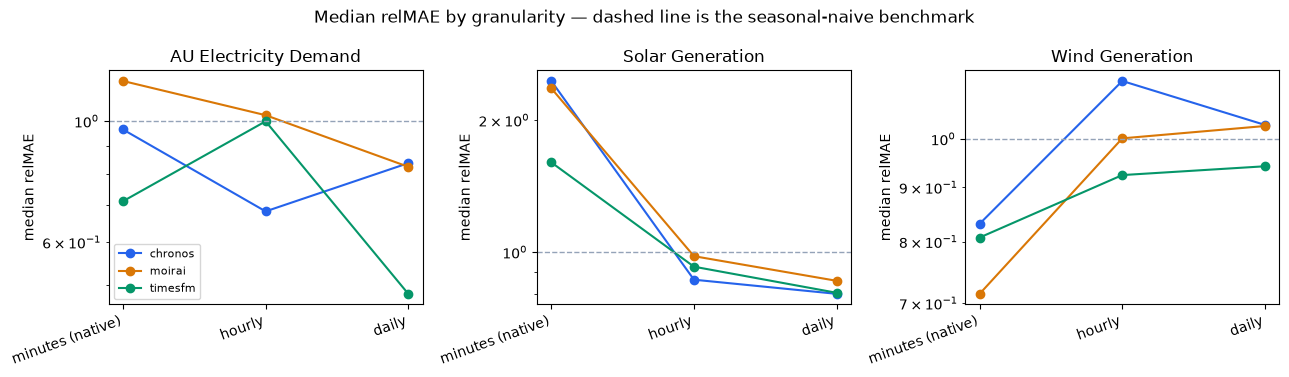

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
for ax, et in zip(axes, C.BASE):
    sub = cl[cl.etype == et]
    for mdl, g in sub.groupby("model"):
        y = [g[g.gran == k]["relMAE"].median() for k in C.GRANULARITIES]
        ax.plot(range(3), y, marker="o", label=mdl, color=PALETTE.get(mdl))
    ax.axhline(1.0, color="#94a3b8", ls="--", lw=1)
    ax.set_xticks(range(3)); ax.set_xticklabels([g["label"] for g in C.GRANULARITIES.values()],
                                                rotation=20, ha="right")
    ax.set_title(C.BASE[et]["label"]); ax.set_ylabel("median relMAE"); ax.set_yscale("log")
axes[0].legend(fontsize=8)
plt.suptitle("Median relMAE by granularity — dashed line is the seasonal-naive benchmark")
plt.tight_layout(); plt.show()

### 4.4 How much did the metric fix change the numbers?

Runs only if the original results file is present.

In [ ]:
OLD = "stage2_all_results.csv"
if os.path.exists(OLD):
    old = pd.read_csv(OLD)
    o = old.groupby(["etype", "gran", "model"])["MASE"].agg(["mean", "median"])
    n = cl.groupby(["etype", "gran", "model"])["MASE"].agg(["mean", "median"])
    cmp = o.join(n, lsuffix="_old", rsuffix="_new")
    cmp["median_ratio"] = (cmp["median_old"] / cmp["median_new"]).round(2)
    print(cmp.round(3).to_string())
    print("\nA large ratio means the old number was inflated by the broken denominator.")
else:
    print(f"{OLD} not found — skipping the before/after comparison.")

                      mean_old  median_old  mean_new  median_new  median_ratio
etype gran   model                                                            
load  1D     chronos     1.077       0.949     1.143       0.965          0.98
             moirai      1.136       0.945     1.210       0.959          0.99
             timesfm     0.593       0.582     0.627       0.611          0.95
      1h     chronos     0.655       0.550     0.716       0.476          1.16
             moirai      0.870       0.796     0.945       0.720          1.11
             timesfm     0.810       0.742     0.902       0.669          1.11
      native chronos     0.757       0.696     0.848       0.663          1.05
             moirai      1.046       0.959     1.161       1.017          0.94
             timesfm     0.627       0.466     0.684       0.488          0.95
solar 1D     chronos     0.794       0.845     0.793       0.827          1.02
             moirai      0.848       0.926     0.836

## 5. What to take from this notebook

- The median MASE table above is the corrected baseline. Use it, not the original.
- Report the degenerate/skipped counts printed in section 2 in your methodology.
- The granularity ordering is **still provisional** — horizon co-varies with granularity
  here. `refined_stage3d_fixed_lead_time` is the test that settles it.

Next: `refined_stage3a_data_characteristics` (no GPU needed).